# Can an LSTM call the next day's direction from hourly bars?

Notebook 11 found that on daily bars nothing called direction, and that a neural
network could not learn even a planted pattern from a few thousand days. The fair next
step is to give a sequence model the data it needs: **hourly bars**, about 50,000 for
Bitcoin and about 42,000 each for gold and US stocks.

**The question.** At each hour: *will the close one day from now be higher than it is
now?* (24 bars ahead for Bitcoin, 16 for the other two, which trade 16 hourly bars a
day with extended hours.)

**Three models**, so the LSTM has something to be compared with:

| model | what it reads |
|---|---|
| **LSTM** | the last 48 bars, one after another: return, high-to-low range, volume, hour of day |
| **small trees** | summaries of the same history: returns over 1 to 168 bars, swings, volume, RSI, hour |
| **logistic regression** | the same summaries |

**Train, validate, test, in time order.** The first 60% of the record trains the
models. The next 20% decides when the LSTM stops training. The last 20% is looked at
once, at the end. A gap is left between the parts so no answer in one depends on prices
in the next.

**The rules and the pass mark were written down before running**
(`docs/DECISIONS.md`, entry 062). A model is "accurate enough to build alerts on" in a
market only if, on test days that do not overlap, it is:

1. right at least 3 points more often than always giving the usual answer;
2. ahead by more than luck, allowing for 9 comparisons;
3. ahead in both halves of the test period.

Rebuild with `uv run python backend/scripts/build_notebooks.py 12_direction_lstm`
(needs `uv sync --extra nlp`; minutes on a GPU).

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from radar.analytics import technical as ta
from radar.db.session import make_engine, session_scope
from radar.models import direction
from radar.pipelines.datasets import load_field
from radar.signals import track
from radar.universe import get_universe

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
pd.set_option("display.width", 240)
engine, universe = make_engine(), get_universe()
NAMES = {"BTC/USD": "Bitcoin", "GLD": "Gold", "SPY": "US stocks"}
COLOURS = {"BTC/USD": "tab:orange", "GLD": "goldenrod", "SPY": "tab:blue"}
HORIZON = {a.symbol: 24 if a.asset_class == "crypto" else 16 for a in universe.primary}
SEEDS = (0, 1, 2)

bars = {}
with session_scope(engine) as session:
    for asset in universe.primary:
        frame = pd.DataFrame(
            {f: load_field(session, [asset.symbol], "1Hour", f)[asset.symbol] for f in ["high", "low", "close", "volume"]}
        ).dropna()
        bars[asset.symbol] = frame
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none (CPU)")
for symbol, frame in bars.items():
    print(f"{NAMES[symbol]:10s} {len(frame):6d} hourly bars, {frame.index[0].date()} to {frame.index[-1].date()}")

GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Bitcoin     50495 hourly bars, 2021-01-01 to 2026-10-07
Gold        41329 hourly bars, 2016-01-04 to 2026-10-06
US stocks   42575 hourly bars, 2016-01-04 to 2026-10-06


## 1. The three parts

Each market's record, cut in time order. Nothing from a later part is ever used to
train or tune.

,market,part,bars,separate days,from,to,ended higher %
0,Bitcoin,train,30082,1253,2021-01-09,2024-06-17,50.894
1,Bitcoin,validate,10027,417,2024-06-20,2025-08-12,53.097
2,Bitcoin,test,10003,416,2025-08-15,2026-10-06,50.435
3,Gold,train,24582,1536,2016-01-26,2022-07-19,52.262
4,Gold,validate,8202,512,2022-07-25,2024-09-11,52.719
5,Gold,test,8186,511,2024-09-17,2026-10-05,55.045
6,US stocks,train,25330,1583,2016-01-22,2022-07-05,56.585
7,US stocks,validate,8451,528,2022-07-11,2024-08-21,54.325
8,US stocks,test,8435,527,2024-08-27,2026-10-05,55.471


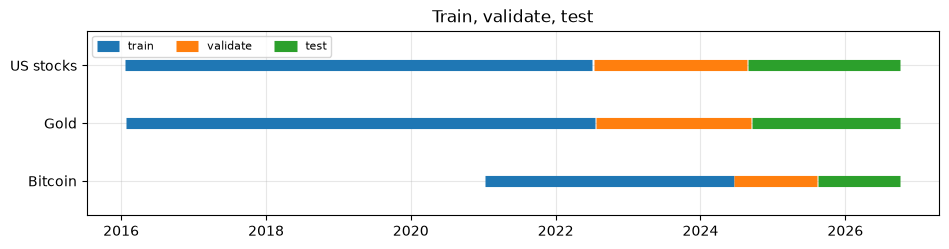

In [2]:
def prepare(symbol, answers):
    """Inputs, answers and the three parts for one market."""
    frame = bars[symbol]
    bar_table, summary_table = direction.bar_inputs(frame), direction.summary_inputs(frame)
    usable = direction.usable_rows(bar_table, answers, direction.WINDOW) & summary_table.notna().all(axis=1).to_numpy()
    parts = direction.split(usable, HORIZON[symbol])
    return {
        "parts": parts,
        "bars": direction.scaled(bar_table, parts.train),
        "summary": direction.scaled(summary_table, parts.train),
        "y": answers.to_numpy(dtype=float),
        "index": frame.index,
    }


real = {s: prepare(s, ta.rises(bars[s]["close"], HORIZON[s])) for s in bars}
fig, ax = plt.subplots(figsize=(11, 2.4))
rows = []
for i, (symbol, data) in enumerate(real.items()):
    parts = data["parts"]
    for name, part, colour in (("train", parts.train, "tab:blue"), ("validate", parts.validation, "tab:orange"), ("test", parts.test, "tab:green")):
        ax.plot(data["index"][part[[0, -1]]], [i, i], lw=8, color=colour, solid_capstyle="butt", label=name if i == 0 else None)
        rows.append({"market": NAMES[symbol], "part": name, "bars": len(part), "separate days": len(part) // HORIZON[symbol],
                     "from": data["index"][part[0]].date(), "to": data["index"][part[-1]].date(), "ended higher %": data["y"][part].mean() * 100})
ax.set_yticks(range(len(real)), [NAMES[s] for s in real])
ax.set(title="Train, validate, test", ylim=(-0.6, len(real) - 0.4))
ax.legend(ncol=3, fontsize=8, loc="upper left")
pd.DataFrame(rows)

## 2. First: can each model learn from this much data?

Before any real answer is used, the answers are replaced by made-up ones with a known
rule: *higher 65% of the time when the last 24 bars rose, 40% when they fell*. A model
that cannot find that has no business being asked about real prices.

"Of the possible gain" is how much of the advantage of knowing the rule the model got.
Under half, and it "cannot learn here".

In [3]:
def run_models(data, lstm_settings=None, seeds=SEEDS):
    """Train all three on the training part; return each one's chances on the test part."""
    parts, y = data["parts"], data["y"]
    settings = lstm_settings or {}
    x_train, x_val, x_test = (direction.windows(data["bars"], rows) for rows in (parts.train, parts.validation, parts.test))
    lstm = np.mean(
        [direction.fit_lstm(x_train, y[parts.train], x_val, y[parts.validation], seed=seed, **settings)(x_test) for seed in seeds],
        axis=0,
    )
    summary = data["summary"]
    return {
        "LSTM": lstm,
        "small trees": ta.fit_trees(summary[parts.train], y[parts.train])(summary[parts.test]),
        "logistic": direction.fit_logistic(summary[parts.train], y[parts.train])(summary[parts.test]),
    }


def scores(symbol, data, chances):
    parts, y = data["parts"], data["y"]
    usual = float(y[parts.train].mean() >= 0.5)
    return {name: direction.score(chance, y[parts.test], usual, HORIZON[symbol]) for name, chance in chances.items()}


rows, planted_data = [], {}
for symbol in bars:
    recent = direction.summary_inputs(bars[symbol])["ret_24"]
    data = prepare(symbol, direction.planted_answers(recent, seed=11))
    planted_data[symbol] = data
    test = data["parts"].test[:: HORIZON[symbol]]
    rule = float(((recent.to_numpy()[test] > 0) == (data["y"][test] == 1)).mean())
    for name, result in scores(symbol, data, run_models(data)).items():
        rows.append({"market": NAMES[symbol], "model": name, "test days": result.n, "right %": result.accuracy * 100,
                     "one answer %": result.baseline * 100, "knowing the rule %": rule * 100,
                     "of the possible gain %": direction.gain_recovered(result, rule) * 100})
planted = pd.DataFrame(rows)
planted["can learn here"] = planted["of the possible gain %"] >= 50
planted

,market,model,test days,right %,one answer %,knowing the rule %,of the possible gain %,can learn here
0,Bitcoin,LSTM,418,58.852,52.392,60.287,81.818,True
1,Bitcoin,small trees,418,60.287,52.392,60.287,100.000,True
2,Bitcoin,logistic,418,56.699,52.392,60.287,54.545,True
3,Gold,LSTM,513,60.429,57.115,62.183,65.385,True
4,Gold,small trees,513,62.183,57.115,62.183,100.000,True
5,Gold,logistic,513,61.793,57.115,62.183,92.308,True
6,US stocks,LSTM,529,59.735,53.119,61.626,77.778,True
7,US stocks,small trees,529,61.626,53.119,61.626,100.000,True
8,US stocks,logistic,529,59.168,53.119,61.626,71.111,True


In [4]:
# Decision 062 allows the LSTM's size and learning rate to be chosen on the planted
# validation part if it fails above. This cell does that only when needed.
LSTM_SETTINGS = {}
failed = planted[(planted["model"] == "LSTM") & ~planted["can learn here"]]
if len(failed):
    grid = []
    for hidden in (16, 32, 64):
        for rate in (0.0003, 0.001, 0.003):
            losses = []
            for symbol, data in planted_data.items():
                parts, y = data["parts"], data["y"]
                predict = direction.fit_lstm(direction.windows(data["bars"], parts.train), y[parts.train],
                                             direction.windows(data["bars"], parts.validation), y[parts.validation], hidden=hidden, rate=rate)
                chance = predict(direction.windows(data["bars"], parts.validation))
                losses.append(((chance > 0.5) == (y[parts.validation] == 1)).mean())
            grid.append({"hidden": hidden, "rate": rate, "planted validation accuracy %": np.mean(losses) * 100})
    grid = pd.DataFrame(grid).sort_values("planted validation accuracy %", ascending=False)
    best = grid.iloc[0]
    LSTM_SETTINGS = {"hidden": int(best["hidden"]), "rate": float(best["rate"])}
    print("LSTM settings chosen on the planted validation part:", LSTM_SETTINGS)
    print(grid.to_string(index=False))
else:
    print("The LSTM passed the planted check in every market with the settings written down; nothing was changed.")

The LSTM passed the planted check in every market with the settings written down; nothing was changed.


## 3. The real test

Now the real answers. Each model is trained on the first part, the LSTM is stopped on
the second, and all three are judged once on the third.

In [5]:
rows, real_chances = [], {}
for symbol, data in real.items():
    real_chances[symbol] = run_models(data, LSTM_SETTINGS)
    for name, result in scores(symbol, data, real_chances[symbol]).items():
        rows.append({"market": NAMES[symbol], "symbol": symbol, "model": name, **result.model_dump()})
results = pd.DataFrame(rows)
surviving = track.survivors([(i, 0, p) for i, p in enumerate(results["p_value"])], direction.SIGNIFICANCE)
results["survives"] = [(i, 0) in surviving for i in range(len(results))]
results["passes"] = [direction.passes(direction.Score(**row[list(direction.Score.model_fields)].to_dict()), row["survives"]) for _, row in results.iterrows()]
shown = results.drop(columns="symbol").copy()
for column in ("accuracy", "baseline", "margin", "first_half_margin", "second_half_margin", "said_higher"):
    shown[column] = shown[column] * 100
shown.rename(columns={"n": "test days", "accuracy": "right %", "baseline": "one answer %", "margin": "margin, points",
                      "first_half_margin": "1st half", "second_half_margin": "2nd half", "said_higher": "said higher %", "p_value": "p"})

,market,model,test days,right %,one answer %,"margin, points",p,1st half,2nd half,said higher %,survives,passes
0,Bitcoin,LSTM,417,53.237,51.079,2.158,0.203,3.365,0.957,72.422,False,False
1,Bitcoin,small trees,417,52.998,51.079,1.918,0.231,2.404,1.435,67.386,False,False
2,Bitcoin,logistic,417,49.880,51.079,-1.199,0.705,-4.808,2.392,60.432,False,False
3,Gold,LSTM,512,53.320,52.930,0.391,0.448,0.781,0.000,59.375,False,False
4,Gold,small trees,512,52.734,52.930,-0.195,0.553,-0.391,0.000,62.305,False,False
5,Gold,logistic,512,52.539,52.930,-0.391,0.588,-0.781,0.000,53.906,False,False
6,US stocks,LSTM,528,55.114,55.114,0.000,0.518,0.000,0.000,100.000,False,False
7,US stocks,small trees,528,54.356,55.114,-0.758,0.654,-1.136,-0.379,96.591,False,False
8,US stocks,logistic,528,54.545,55.114,-0.568,0.621,-0.758,-0.379,99.053,False,False


Passed the mark of decision 062: 0 of 9


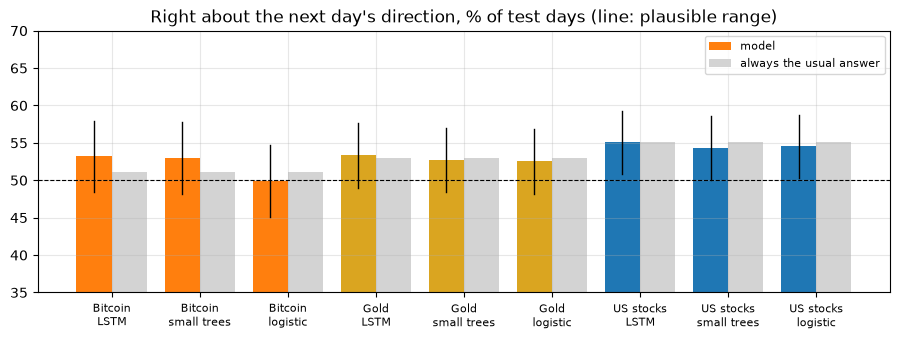

In [6]:
fig, ax = plt.subplots(figsize=(11, 3.4))
x = np.arange(len(results))
ax.bar(x - 0.2, results["accuracy"] * 100, width=0.4, color=[COLOURS[s] for s in results["symbol"]], label="model")
ax.bar(x + 0.2, results["baseline"] * 100, width=0.4, color="lightgrey", label="always the usual answer")
ax.axhline(50, color="black", lw=0.8, ls="--")
for xi, row in zip(x, results.itertuples()):
    low, high = track.wilson(round(row.accuracy * row.n), row.n)
    ax.plot([xi - 0.2, xi - 0.2], [low * 100, high * 100], color="black", lw=1)
ax.set_xticks(x, [f"{m}\n{k}" for m, k in zip(results["market"], results["model"])], fontsize=8)
ax.set(title="Right about the next day's direction, % of test days (line: plausible range)", ylim=(35, 70))
ax.legend(fontsize=8)
print(f"Passed the mark of decision 062: {int(results['passes'].sum())} of {len(results)}")

## 4. Does the model's confidence mean anything?

A model gives a chance, not just an answer. If its confidence were worth something,
the days it is most sure of "higher" would end higher more often than the days it is
least sure. This was not part of the written test; it is shown because "how accurate
when it is confident" is the natural next question.

,market,model,least sure fifth: ended higher %,most sure fifth: ended higher %
0,Bitcoin,LSTM,45.238,46.429
1,Bitcoin,small trees,47.619,59.524
2,Bitcoin,logistic,53.571,51.190
3,Gold,LSTM,52.427,55.340
4,Gold,small trees,51.456,55.340
5,Gold,logistic,54.369,54.369
6,US stocks,LSTM,60.377,56.604
7,US stocks,small trees,48.113,60.377
8,US stocks,logistic,58.491,54.717


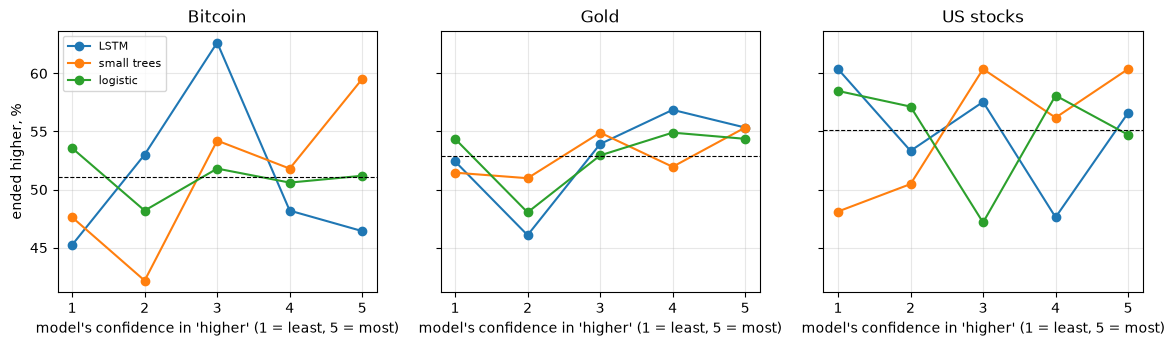

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4), sharey=True)
rows = []
for ax, (symbol, data) in zip(axes, real.items()):
    y = data["y"][data["parts"].test][:: HORIZON[symbol]]
    for name, chance in real_chances[symbol].items():
        chance = chance[:: HORIZON[symbol]]
        fifths = pd.qcut(pd.Series(chance).rank(method="first"), 5, labels=False)
        share = pd.Series(y).groupby(fifths).mean() * 100
        ax.plot(range(1, 6), share.to_numpy(), marker="o", label=name)
        rows.append({"market": NAMES[symbol], "model": name, "least sure fifth: ended higher %": share.iloc[0], "most sure fifth: ended higher %": share.iloc[-1]})
    ax.axhline(y.mean() * 100, color="black", lw=0.8, ls="--")
    ax.set(title=NAMES[symbol], xlabel="model's confidence in 'higher' (1 = least, 5 = most)")
axes[0].set_ylabel("ended higher, %")
axes[0].legend(fontsize=8)
pd.DataFrame(rows)

## 5. As a rule: hold only when the model says "higher"

Decided once a day, with 0.1% taken off each time the position changes, against
holding throughout the same test days. Reported, not judged.

,market,model,return %,holding %,deepest fall %,holding fall %,Sharpe difference,p,time held %
0,Bitcoin,LSTM,-33.681,-27.491,-40.248,-52.814,-0.379,0.594,72.422
1,Bitcoin,small trees,-21.652,-27.491,-41.539,-52.814,-0.017,0.974,67.386
2,Bitcoin,logistic,-53.470,-27.491,-61.127,-52.814,-1.283,0.022,60.432
3,Gold,LSTM,16.787,60.001,-27.571,-24.917,-0.569,0.172,59.375
4,Gold,small trees,31.219,60.001,-19.931,-24.917,-0.244,0.564,62.305
5,Gold,logistic,19.077,60.001,-21.147,-24.917,-0.527,0.340,53.906
6,US stocks,LSTM,41.477,41.477,-18.732,-18.732,0.000,1.000,100.000
7,US stocks,small trees,31.669,41.477,-18.732,-18.732,-0.211,0.031,96.591
8,US stocks,logistic,39.976,41.477,-18.732,-18.732,-0.015,0.857,99.053


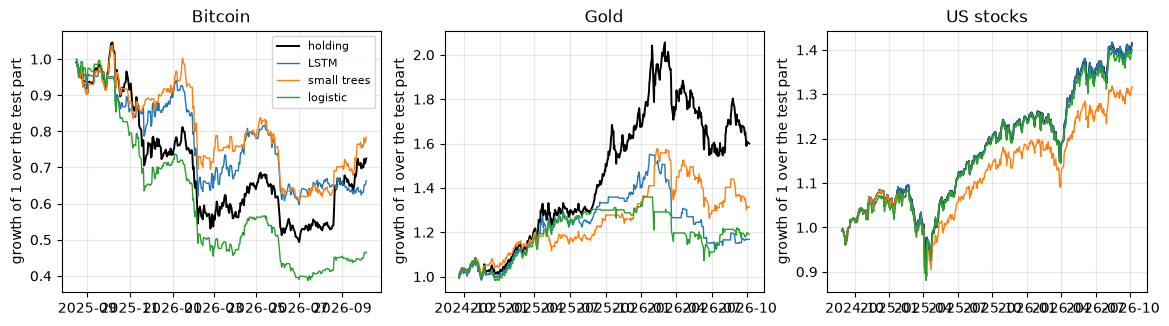

In [8]:
rows = []
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
for ax, (symbol, data) in zip(axes, real.items()):
    test = data["parts"].test[:: HORIZON[symbol]]
    close = bars[symbol]["close"].iloc[test]
    returns = close.pct_change()
    per_year = 365 if symbol == "BTC/USD" else 252
    hold = ta.backtest(returns, pd.Series(1.0, index=close.index))
    ax.plot(hold.index, (1 + hold).cumprod(), color="black", lw=1.4, label="holding")
    for name, chance in real_chances[symbol].items():
        weight = pd.Series((chance[:: HORIZON[symbol]] > 0.5).astype(float), index=close.index)
        rule = ta.backtest(returns, weight)
        gap, p_value = ta.sharpe_difference(rule, hold, per_year, draws=2000)
        ax.plot(rule.index, (1 + rule).cumprod(), lw=1, label=name)
        rows.append({"market": NAMES[symbol], "model": name, "return %": ((1 + rule).prod() - 1) * 100, "holding %": ((1 + hold).prod() - 1) * 100,
                     "deepest fall %": ta.deepest_fall(rule) * 100, "holding fall %": ta.deepest_fall(hold) * 100,
                     "Sharpe difference": gap, "p": p_value, "time held %": weight.mean() * 100})
    ax.set(title=NAMES[symbol], ylabel="growth of 1 over the test part")
axes[0].legend(fontsize=8)
pd.DataFrame(rows)

## 6. The result

**The models can learn. There was nothing of useful size for them to learn.**

| step | result |
|---|---|
| planted pattern, hourly bars | all three models found it in all three markets; the LSTM got 65% to 82% of the possible gain, the small trees all of it |
| real answers, 9 comparisons | **0 passed the mark** |
| best single case | LSTM on Bitcoin: right 53.2% of test days against 51.1%, ahead in both halves, but 2.2 points is under the 3-point mark and well within luck |
| US stocks | the LSTM said "higher" on every single test day: what it learned is "US stocks usually rise" |
| gold | all three level with the baseline |
| as a rule, after costs | none beat holding; in gold all three earned much less, because a model that steps out of a rising market misses the rise |

**What changed from notebook 11.** There, the network could not learn even a planted
pattern, so its "no" meant nothing. Here, with ten times the data, the LSTM passed the
planted check with the settings written down beforehand and nothing was adjusted. So
this "no" is a real one: a pattern worth 25 points would have been found, and nothing
within reach of this test is there.

**On confidence (section 4).** In Bitcoin and US stocks, the days the small trees were
most sure of ended higher more often than the days they were least sure (about 60%
against 48%). Each fifth holds only 85 to 105 days, where a range is about 10 points
either way, and this was looked at after the fact, so it is not evidence. It is the one
thing here worth writing down as a test for new data, not something to act on.

**My guess beforehand (decision 062), checked.** Right that the LSTM would pass the
planted check on hourly bars. Right that no model would pass on real answers. I said
accuracy would sit within 2 points of the baseline; the LSTM on Bitcoin was 2.2 ahead,
so slightly off.

## 7. What this means

The question was whether an LSTM, or anything else, could call direction well enough to
send alerts on. On prices and volume of these three markets, **no**: not daily, not
hourly, not with trees, a logistic regression, or an LSTM. The limit is not the model.
Three different kinds of model, all shown able to learn, agree.

What could still change the answer is **different information**, not a different
network:

- **Many markets at once.** Published results that find a small edge pool thousands of
  stocks. One market gives one history; five hundred give five hundred.
- **Information that is not in the price**: positioning, funding rates, order flow.
  RADAR does not collect these.

And one thing already measured does not depend on calling direction at all: in notebook
11, holding less when swings are high, or stepping aside below the 200-day average,
made the deepest fall far shallower in Bitcoin and US stocks. That was reported, not
tested as a claim of its own, so it needs its own written test on markets it has not
seen before it can be the basis of an alert.

**Limits.** About 420 to 530 separate test days per market: an edge under about 5
points cannot be seen here. A model can have a 1 or 2 point edge and fail this test. An
edge that small, on one market, after costs, is not one to send alerts on.